<a href="https://colab.research.google.com/github/okana2ki/multiV/blob/main/rent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 可視化

## 散布図

In [ ]:
!pip install japanize-matplotlib

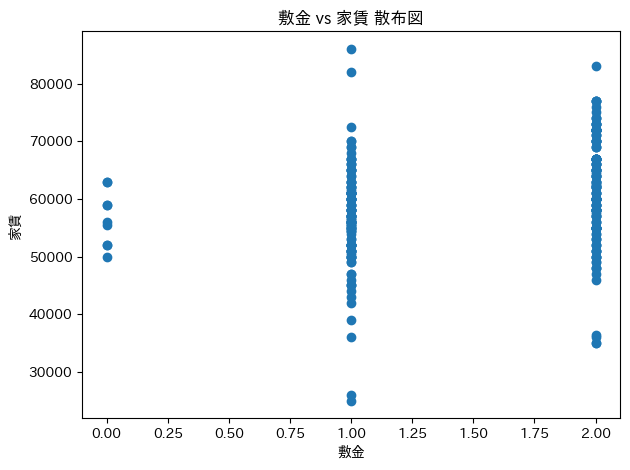

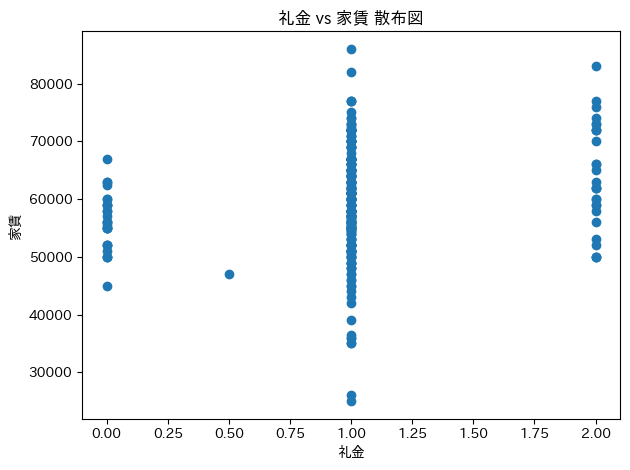

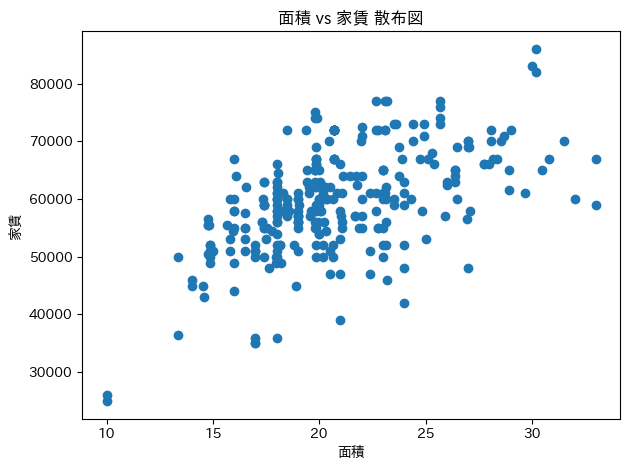

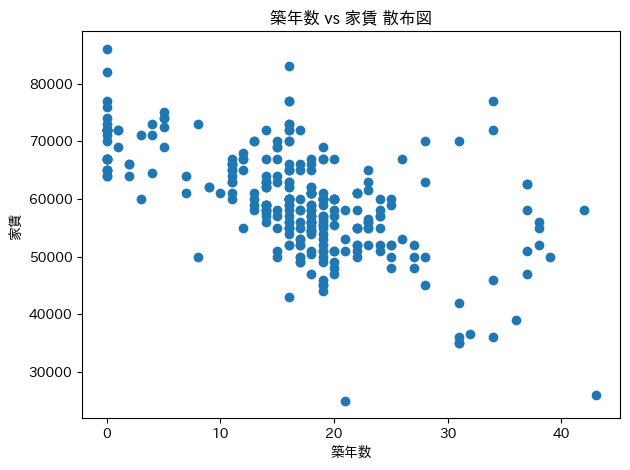

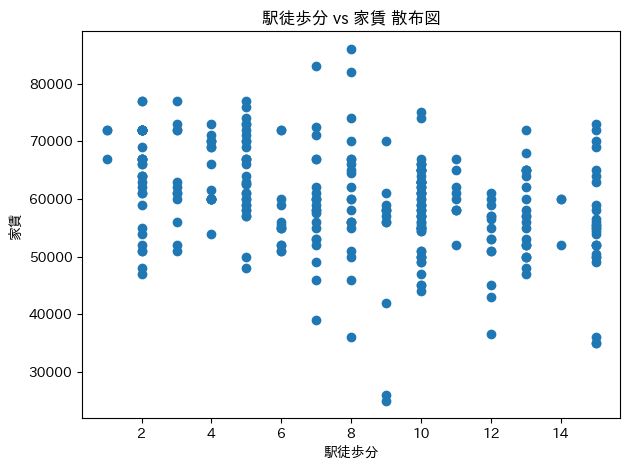

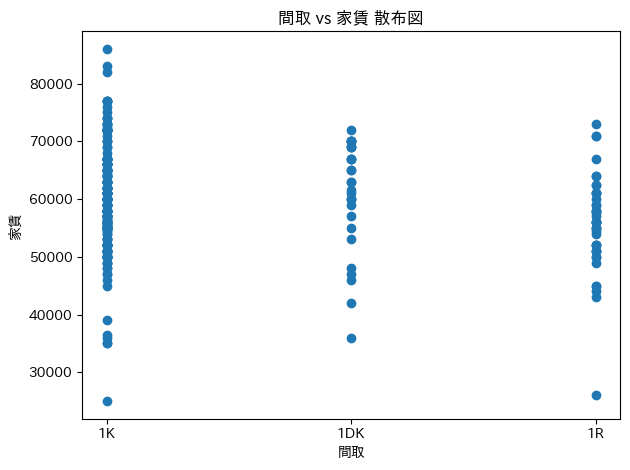

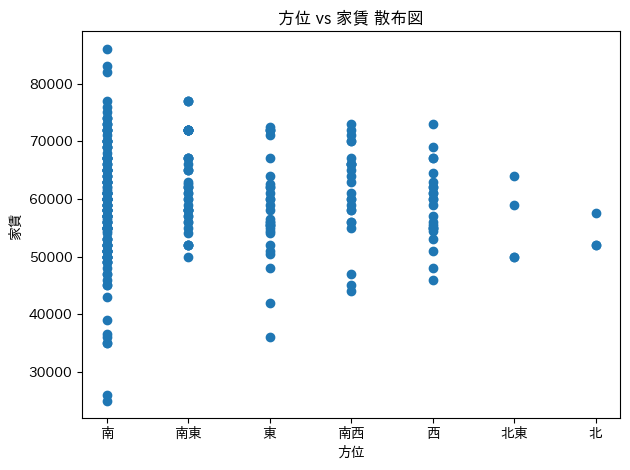

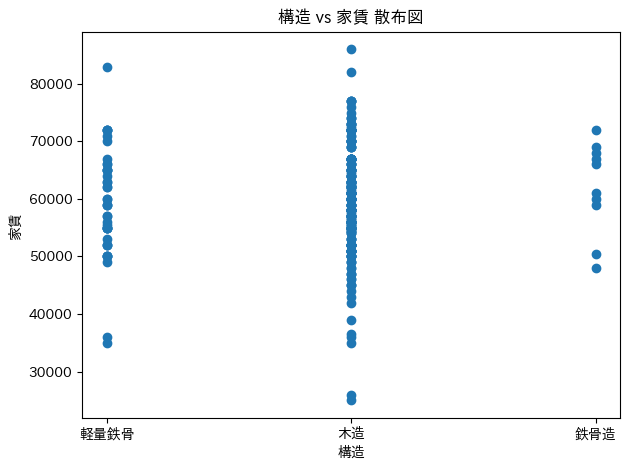

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # ここを追加

# データの読み込み
df = pd.read_excel('/content/rent_original.xlsx')

# 目的変数と説明変数の設定
dependent_var = '家賃'
explanatory_vars = df.loc[:, '敷金':'構造'].columns

# 各説明変数と目的変数の散布図を作成
for var in explanatory_vars:
    plt.figure()
    plt.scatter(df[var], df[dependent_var])
    plt.xlabel(var)
    plt.ylabel(dependent_var)
    plt.title(f'{var} vs {dependent_var} 散布図')
    plt.tight_layout()
    plt.show()


## 箱ひげ図（平均値表示付き）

### バグあり

<Figure size 1000x600 with 0 Axes>

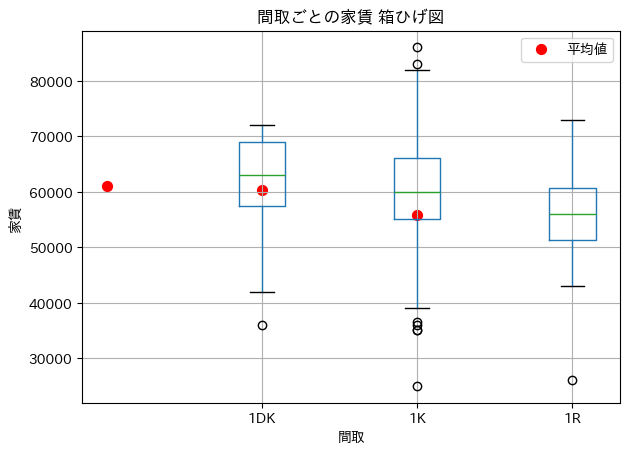

<Figure size 1000x600 with 0 Axes>

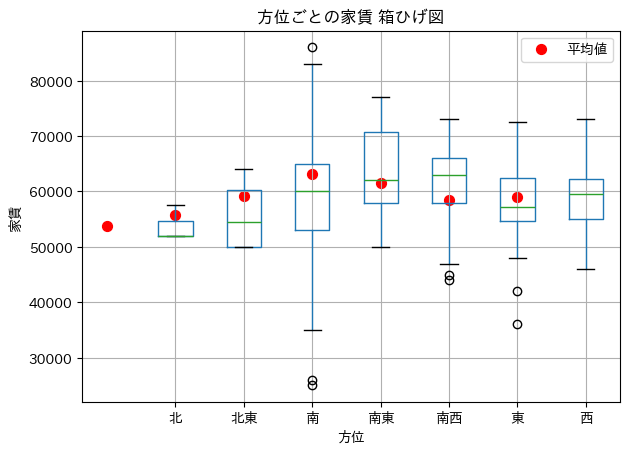

<Figure size 1000x600 with 0 Axes>

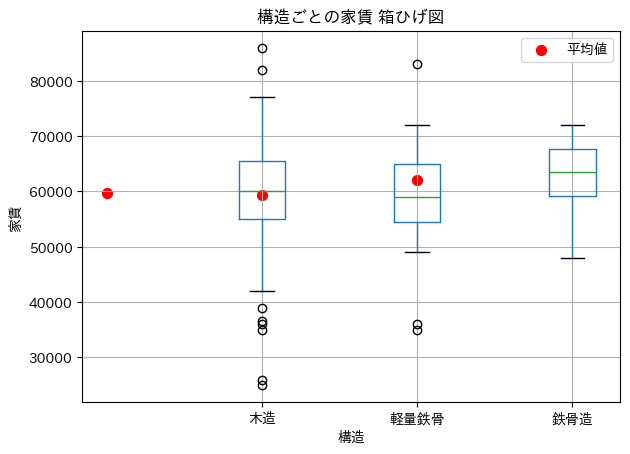

In [12]:
# prompt: 家賃の箱ひげ図を描く。横軸は間取、方位、構造の3通りで描く。比較しやすいようにグリッドを表示する。平均値もプロットする。

import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# データの読み込み
df = pd.read_excel('/content/rent_original.xlsx')

# 目的変数と説明変数の設定
dependent_var = '家賃'
categorical_vars = ['間取', '方位', '構造'] # 箱ひげ図を描画するカテゴリカル変数

# 各カテゴリカル変数と目的変数の箱ひげ図を作成
for var in categorical_vars:
    plt.figure(figsize=(10, 6))
    df.boxplot(column=dependent_var, by=var, grid=True)

    # 平均値を計算し、プロット
    means = df.groupby(var)[dependent_var].mean()
    plt.scatter(x=means.index, y=means.values, marker='o', color='red', s=50, label='平均値')

    plt.xlabel(var)
    plt.ylabel(dependent_var)
    plt.title(f'{var}ごとの{dependent_var} 箱ひげ図')
    plt.suptitle('') # byによって自動で入るタイトルを削除
    plt.grid(True) # グリッドを表示
    plt.legend() # 平均値の凡例を表示
    plt.tight_layout()
    plt.show()

### デバッグ後

<Figure size 1000x600 with 0 Axes>

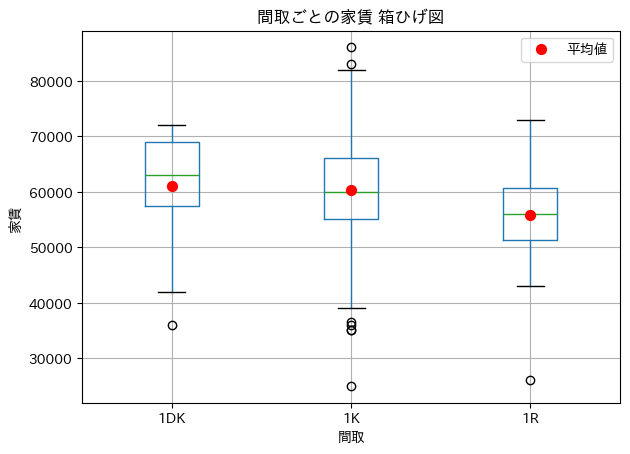

<Figure size 1000x600 with 0 Axes>

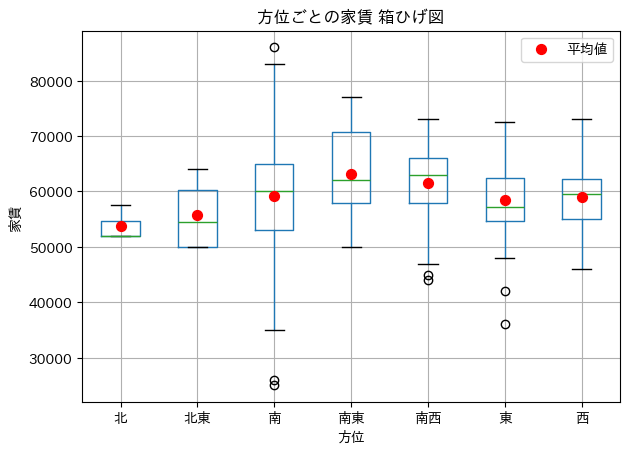

<Figure size 1000x600 with 0 Axes>

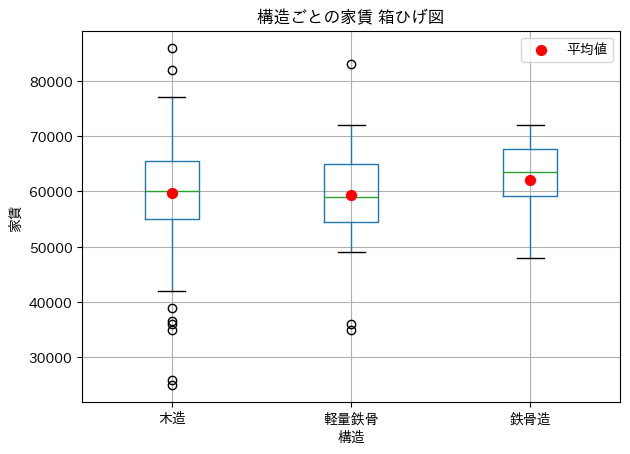

In [13]:
# prompt: 平均値の表示が左に1列ずれています。修正して下さい。

# 各カテゴリカル変数と目的変数の箱ひげ図を作成
for var in categorical_vars:
    plt.figure(figsize=(10, 6))
    df.boxplot(column=dependent_var, by=var, grid=True)

    # 平均値を計算し、プロット
    means = df.groupby(var)[dependent_var].mean()
    # 平均値のx座標を計算
    x_positions = range(1, len(means) + 1)
    plt.scatter(x=x_positions, y=means.values, marker='o', color='red', s=50, label='平均値', zorder=3) # zorderを追加して手前に表示

    plt.xlabel(var)
    plt.ylabel(dependent_var)
    plt.title(f'{var}ごとの{dependent_var} 箱ひげ図')
    plt.suptitle('') # byによって自動で入るタイトルを削除
    plt.grid(True) # グリッドを表示
    plt.legend() # 平均値の凡例を表示
    plt.tight_layout()
    plt.show()


# ダミー変数を使用して重回帰分析

In [14]:
# prompt: 家賃を目的変数、面積、築年数、駅徒歩分、間取、方位、構造を説明変数として、statsmodelsを使って重回帰分析する。間取、方位、構造は、ダミー変数とする。

import statsmodels.api as sm
import statsmodels.formula.api as smf

# ダミー変数を作成
df_dummies = pd.get_dummies(df, columns=['間取', '方位', '構造'], drop_first=True)

# 回帰分析に使用する説明変数を定義（ダミー変数を含む）
explanatory_vars_with_dummies = ['面積', '築年数', '駅徒歩分'] + list(df_dummies.columns[df_dummies.columns.str.startswith(('間取_', '方位_', '構造_'))])

# 回帰式を作成
formula = f'{dependent_var} ~ {" + ".join(explanatory_vars_with_dummies)}'

# 重回帰分析を実行
model = smf.ols(formula, data=df_dummies).fit()

# 結果を表示
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     家賃   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     44.12
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           2.62e-60
Time:                        13:10:29   Log-Likelihood:                -2960.2
No. Observations:                 297   AIC:                             5948.
Df Residuals:                     283   BIC:                             6000.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        3.983e+04   4080.128     

## 結果の考察

- 間取の2つのダミー変数のP値が5%有意水準で有意なので、それが効いて、Adj. R-squared = 0.654 と少し改善されたのではないか。（面積、築年数、駅徒歩分の3つの数値変数だけだとAdj. R-squared = 0.637だった。）

- 方位をダミー変数でなく、上手に数値化すると、もう少し改善できる可能性があるかも。

# 方位をデータ分布を考慮して数値化し、再度分析を試みる

In [15]:
# prompt: 方位をダミー変数でなく、次の通り数値化して、再度、重回帰分析を試みる。南東=2, 南西=2, 南=1, 東=1, 西=1, 北東=0, 北=0

# 方位を数値にマッピング
direction_mapping = {
    '南東': 2,
    '南西': 2,
    '南': 1,
    '東': 1,
    '西': 1,
    '北東': 0,
    '北': 0,
    '北西': 0 # '北西' のマッピングが指定されていないため、北や北東と同じ0と仮定
}

# 新しい数値化された方位カラムを作成
df['方位_数値'] = df['方位'].map(direction_mapping)

# ダミー変数を作成（方位は数値化したものを使用し、他のカテゴリ変数はダミー変数化）
df_dummies_numeric_direction = pd.get_dummies(df.drop('方位', axis=1), columns=['間取', '構造'], drop_first=True)

# 数値化された方位カラムを結合
df_dummies_numeric_direction['方位_数値'] = df['方位_数値']


# 回帰分析に使用する説明変数を定義（数値化された方位と他のダミー変数を含む）
explanatory_vars_numeric_direction = ['面積', '築年数', '駅徒歩分', '方位_数値'] + list(df_dummies_numeric_direction.columns[df_dummies_numeric_direction.columns.str.startswith(('間取_', '構造_'))])

# 回帰式を作成
formula_numeric_direction = f'{dependent_var} ~ {" + ".join(explanatory_vars_numeric_direction)}'

# 重回帰分析を実行
model_numeric_direction = smf.ols(formula_numeric_direction, data=df_dummies_numeric_direction).fit()

# 結果を表示
print(model_numeric_direction.summary())

                            OLS Regression Results                            
Dep. Variable:                     家賃   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     70.63
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           1.89e-63
Time:                        13:38:57   Log-Likelihood:                -2963.4
No. Observations:                 297   AIC:                             5945.
Df Residuals:                     288   BIC:                             5978.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        4.219e+04   2917.908     

## 結果の考察

- 数値化した方位のP値は5%有意水準で有意とはならず、評価指標も、Adj. R-squared = 0.653 とほとんど改善されなかった。

- 方位を2次元座標で数値化するのも試してみる？

# 方位を2次元に数値化して再度分析を試みる

東西南北等の方位を、単位円上の座標値で数値化する。すなわち、北=(0,1), 東=(1,0), 北東=(1/root_2,1/root_2), など。

In [16]:
# prompt: 方位を、次のように2次元に数値化して、再度重会議分析を試みる。東西南北等の方位を、単位円上の座標値で数値化する。すなわち、北=(0,1), 東=(1,0), 北東=(1/root_2,1/root_2), など。

import numpy as np

# 方位を2次元座標にマッピングする関数
def direction_to_coords(direction):
    if direction == '北':
        return (0, 1)
    elif direction == '北東':
        return (1/np.sqrt(2), 1/np.sqrt(2))
    elif direction == '東':
        return (1, 0)
    elif direction == '南東':
        return (1/np.sqrt(2), -1/np.sqrt(2))
    elif direction == '南':
        return (0, -1)
    elif direction == '南西':
        return (-1/np.sqrt(2), -1/np.sqrt(2))
    elif direction == '西':
        return (-1, 0)
    elif direction == '北西':
        return (-1/np.sqrt(2), 1/np.sqrt(2))
    else:
        return (0, 0) # その他の場合は原点とするなど、適宜処理を検討

# 方位を2つのカラム (方位_X, 方位_Y) に変換
df[['方位_X', '方位_Y']] = df['方位'].apply(direction_to_coords).tolist()

# ダミー変数を作成（方位は2次元座標を使用し、他のカテゴリ変数はダミー変数化）
# 元の'方位'カラムはドロップ
df_dummies_2d_direction = pd.get_dummies(df.drop('方位', axis=1), columns=['間取', '構造'], drop_first=True)

# 2次元化された方位カラムを結合
# apply().tolist()を使うとDataFrameに直接代入できないため、dropとjoinを考慮
df_dummies_2d_direction['方位_X'] = df['方位_X']
df_dummies_2d_direction['方位_Y'] = df['方位_Y']

# 回帰分析に使用する説明変数を定義（2次元化された方位と他のダミー変数を含む）
explanatory_vars_2d_direction = ['面積', '築年数', '駅徒歩分', '方位_X', '方位_Y'] + list(df_dummies_2d_direction.columns[df_dummies_2d_direction.columns.str.startswith(('間取_', '構造_'))])

# 回帰式を作成
formula_2d_direction = f'{dependent_var} ~ {" + ".join(explanatory_vars_2d_direction)}'

# 重回帰分析を実行
model_2d_direction = smf.ols(formula_2d_direction, data=df_dummies_2d_direction).fit()

# 結果を表示
print(model_2d_direction.summary())

                            OLS Regression Results                            
Dep. Variable:                     家賃   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     63.82
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           2.52e-63
Time:                        13:54:13   Log-Likelihood:                -2961.4
No. Observations:                 297   AIC:                             5943.
Df Residuals:                     287   BIC:                             5980.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        4.214e+04   2888.887     

## 結果の考察

- 方位XのP値が5%有意水準で有意となり、Adj. R-squared = 0.656 とわずかだが改善？